#Introducere în Machine Learning


###Laboratorul 1

 Sarcini practice bazate pe setul de date Iris.csv

- Pandas https://pandas.pydata.org/docs/,
- Matplotlib https://matplotlib.org/,
- Seaborn https://seaborn.pydata.org/,
- Intel Extension for Scikit-learn https://uxlfoundation.github.io/scikit-learn-intelex/latest/index.html

In [20]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl 



### Exercițiul 1: Încărcarea și analiza inițială a datelor

Folosind bibliotecile pandas și numpy, încărcați fișierul Iris_Data.csv din directorul data. Afișați pe ecran:
 - Numărul total de rânduri.
 - Numele tuturor coloanelor.
 - Tipurile de date pentru fiecare coloană.

In [2]:
path = '/Users/mac007/workfiles/master_usm/ml/datasets/dataset_iris.csv'

dataframe = pd.read_csv(path)

df = dataframe.copy()



df.shape


(150, 5)

###Exercițiul 2: Curățarea și transformarea datelor text

Explorați valorile din coloana species.
Observați că toate încep cu prefixul Iris-.

Scrieți cod pentru a elimina acest prefix din toate rândurile (astfel încât să rămână doar setosa, versicolor, virginica).

In [3]:

df["species"] = df["species"].str.replace("Iris-", "" )

df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Exercițiul 3: Statistica descriptivă și amplitudinea (range)

Folosind metoda describe()creați un rând nou în tabel numit range, care calculează diferența dintre valoarea maximă și valoarea minimă pentru fiecare coloană numerică.

In [5]:

stats_df = df.describe()


stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']


# stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']

out_fields = ["mean", "25%", "50%", "75%", "range"]

stats_df = stats_df.loc[out_fields]

stats_df.rename({"50%": "median"}, inplace=True)










### Exercițiul 4: Grupatarea datelor pe specii (Media și Mediana)
 Grupați setul de date după coloana species  și aplicați simultan funcțiile de medie (mean)și mediană (median) pentru toate coloanele numerice.

In [6]:
num_cols = df.select_dtypes('number').columns
by_species = df.groupby('species')[num_cols].agg(['mean', 'median'])
print(by_species)


           sepal_length        sepal_width        petal_length         \
                   mean median        mean median         mean median   
species                                                                 
setosa            5.006    5.0       3.418    3.4        1.464   1.50   
versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
virginica         6.588    6.5       2.974    3.0        5.552   5.55   

           petal_width         
                  mean median  
species                        
setosa           0.244    0.2  
versicolor       1.326    1.3  
virginica        2.026    2.0  


### Exercițiul 5: Agregare avansată utilizând un dicționar

Folosind metoda agg() pentru datele grupate
aplicați următoarele reguli: pentru sepal_length, sepal_width și petal_width calculați media și mediana, iar pentru petal_length — doar valoarea maximă (max).

In [7]:
rezultat = df.groupby("species").agg({
    "sepal_length": ["mean", "median"],
    "sepal_width":  ["mean", "median"],
    "petal_width":  ["mean", "median"],
    "petal_length": "max",
})

print(rezultat)

           sepal_length        sepal_width        petal_width         \
                   mean median        mean median        mean median   
species                                                                
setosa            5.006    5.0       3.418    3.4       0.244    0.2   
versicolor        5.936    5.9       2.770    2.8       1.326    1.3   
virginica         6.588    6.5       2.974    3.0       2.026    2.0   

           petal_length  
                    max  
species                  
setosa              1.9  
versicolor          5.1  
virginica           6.9  


### Exercițiul 6: Vizualizarea datelor cu ajutorul Matplotlib

Importați matplotlib.pyplot și construiți un diagramă de dispersie (scatter plot) care reflectă dependența dintre sepal_length (axa X) și sepal_width (axa Y).
   Adăugați etichete pentru axe și un titlu.

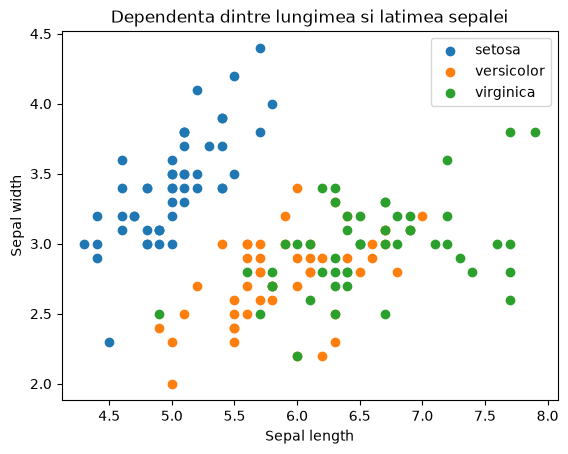

In [8]:
for specie, grup in df.groupby("species"):
    plt.scatter(grup["sepal_length"], grup["sepal_width"], label=specie)
    


plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Dependenta dintre lungimea si latimea sepalei")
plt.legend()
plt.show()

### Exercițiul 7: Numărarea frecvenței speciilor
 Folosiți o metodă specială din Pandas pentru a afla numărul exact de înregistrări pentru fiecare specie în parte din setul de date curățat.

In [9]:
frequence = df["species"].value_counts() 
print(frequence)

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### Exercițiul 8: Accelerarea Scikit-learn folosind Intel® Extension

Scrieți liniile de cod care trebuie executate imediat după importarea bibliotecii sklearn pentru a activa optimizarea oneDAL

In [ ]:
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
except ImportError:
    print("sklearnex nu este disponibil pe acest sistem (Apple Silicon) se foloseste scikit-learn standard.")

sklearnex nu este disponibil pe acest sistem (Apple Silicon); se folosește scikit-learn standard.


### Exercițiul 9: Framework-uri în Machine Learning\

Bazându-vă pe materialele introductive, explicați de ce framework-urile sunt mai mult decât simple biblioteci și ce beneficiu material aduce optimizarea hiperparametrilor.

##### Framework-urile sunt mai mult decat biblioteci deoarece stabilesc structura si modul de organizare a codului, nu doar ofera functii reutilizabile 

#### Optimizarea hiperparametrilor ne permite alegerea configuratiei care ofera cele mai bune rezultate modelului, imbunatatind precizia si performanta acestuia 


### Exercițiul 10: Cerințe preliminare ale cursului
  Enumerați cel puțin trei direcții de bază  (în matematică și programare) necesare pentru parcurgerea cu succes a cursului de Machine Learning

1. Algebra liniara: vectori, matrici si operatii cu ele
2. Statistica si probabilitati: medie, mediana, variatie, distributii si probabilitati
3. Programare in Python

### Exercițiul 11: Vizualizarea avansată a distribuțiilor cu Matplotlib (Histograme)
 Folosind Matplotlib, construiți o figură cu două subgrafice (subplots) alături unul de celălalt (1 rând, 2 coloane):
 - Pe primul grafic afișați histogramei de distribuție pentru petal_length.
 - Pe al doilea grafic afișați histogramei de distribuție pentru petal_width.

 Adăugați titluri și etichete la axe pentru fiecare grafic.

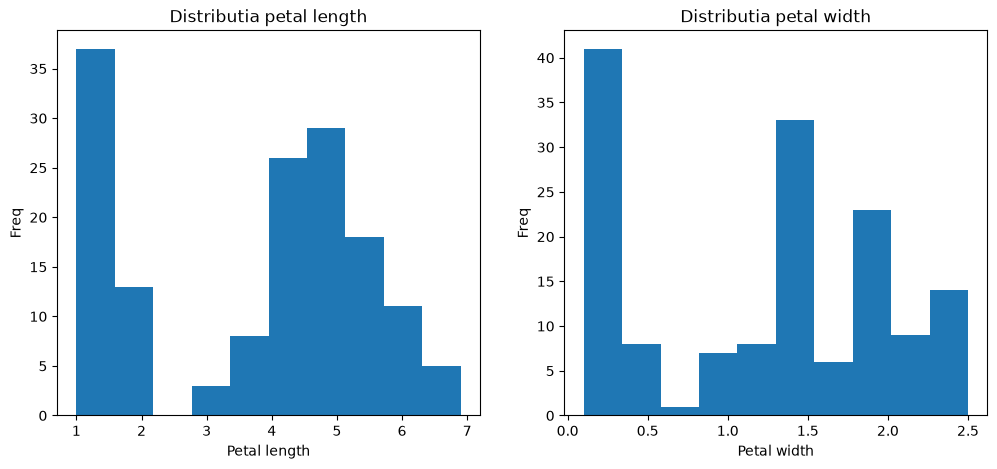

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#petal lenght 
axes[0].hist(df["petal_length"], bins=10)
axes[0].set_title("Distributia petal length")
axes[0].set_xlabel("Petal length")
axes[0].set_ylabel("Freq")

#petal width

axes[1].hist(df["petal_width"], bins=10)
axes[1].set_title("Distributia petal width")
axes[1].set_xlabel("Petal width")
axes[1].set_ylabel("Freq")

plt.show()

### Exercițiul 12: Explorarea datelor cu ajutorul Seaborn (Pairplot)

Importați biblioteca seaborn și construiți o matrice de grafice perechi (sns.pairplot)  pentru întregul set de date Iris, colorând punctele în funcție de specia plantei (species).

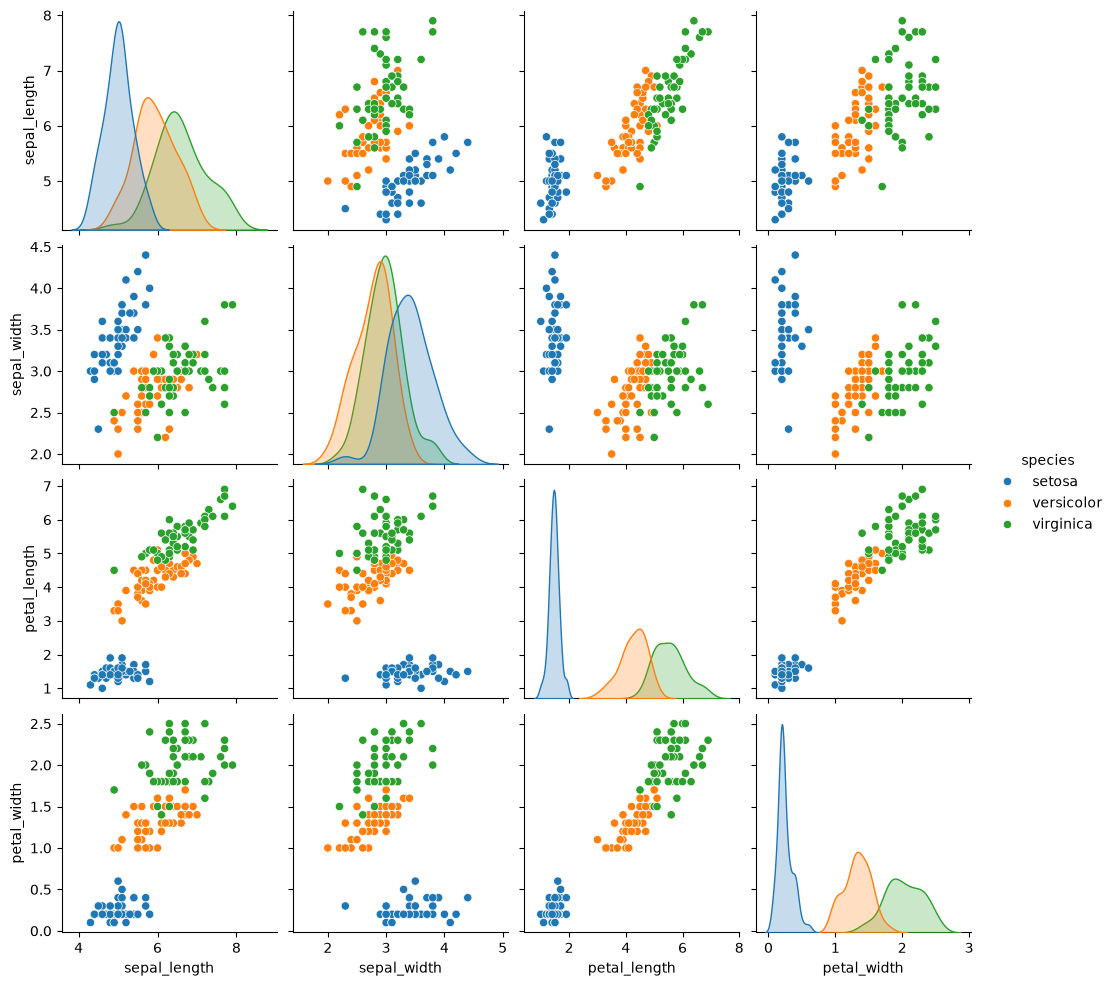

In [21]:
sns.pairplot(df, hue="species")

### Exercițiul 13: Analiza valorilor aberante prin Boxplot (Seaborn)

Folosind biblioteca Seaborn, construiți un diagramă box-and-whisker (sns.boxplot), pentru a compara distribuția lungimii petalelor (petal_length) pentru fiecare specie în parte (species).

<Axes: xlabel='species', ylabel='petal_length'>

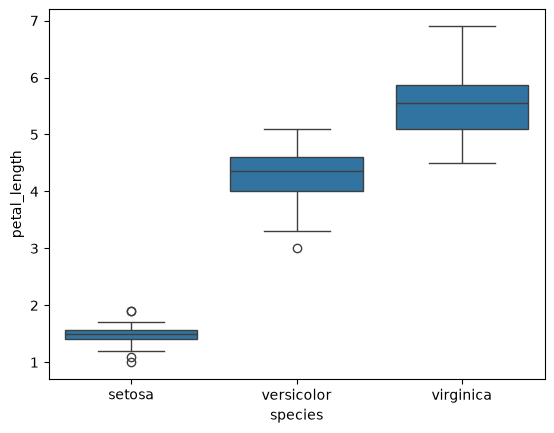

In [22]:
sns.boxplot(x="species", y="petal_length", data=df)

### Exercițiul 14: Harta termică a corelațiilor (Seaborn Heatmap)
 Calculați matricea de corelație a caracteristicilor numerice folosind metoda corr(), iar apoi vizualizați-o sub formă de hartă termică (sns.heatmap), incluzând afișarea valorilor numerice în interiorul celulelor (annot=True).

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109369      0.871754     0.817954
sepal_width      -0.109369     1.000000     -0.420516    -0.356544
petal_length      0.871754    -0.420516      1.000000     0.962757
petal_width       0.817954    -0.356544      0.962757     1.000000


<Axes: >

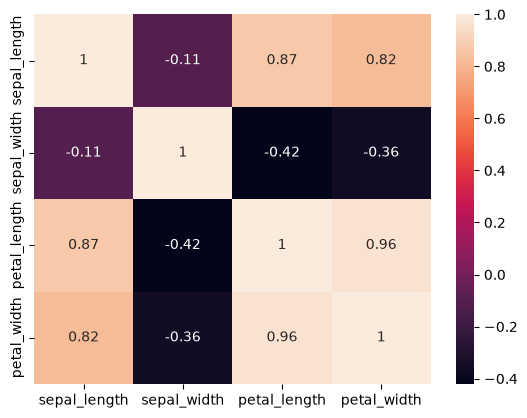

In [28]:
numeric_columns = ["sepal_length", "sepal_width","petal_length","petal_width"]
correlation = df[numeric_columns].corr()

print(correlation)

sns.heatmap(data=correlation, annot=True)